# EDA: STIX Solar Flares
Einfache Untersuchung der Flare-Daten.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Daten einlesen und Übersicht verschaffen
DATA_PATH = "../data/stix_flares.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
0,2021-02-14T01:41:06.670,2021-02-14T01:49:14.671,2021-02-14T01:44:14.670,1983,463,183,927,543,271.0,49.0,...,2102140144,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,/Users/laurahayes/flare_analysis/new_stix_flar...
1,2021-02-14T13:21:34.741,2021-02-14T13:33:02.742,2021-02-14T13:24:54.741,1855,271,151,927,543,271.0,49.0,...,2102141324,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,/Users/laurahayes/flare_analysis/new_stix_flar...
2,2021-02-14T19:34:46.779,2021-02-14T19:43:18.780,2021-02-14T19:36:46.779,1215,271,151,927,495,247.0,49.0,...,2102141936,NaN,B4,B6,B5,4.000000e-07,6.000000e-07,5.000000e-07,True,/Users/laurahayes/flare_analysis/new_stix_flar...
3,2021-02-15T07:22:43.151,2021-02-15T07:34:43.153,2021-02-15T07:27:03.152,1343,215,91,927,543,271.0,49.0,...,2102150727,NaN,B4,B7,B5,4.000000e-07,7.000000e-07,5.000000e-07,True,/Users/laurahayes/flare_analysis/new_stix_flar...
4,2021-02-15T08:14:39.159,2021-02-15T08:28:35.160,2021-02-15T08:16:35.159,1855,271,91,927,495,271.0,49.0,...,2102150816,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,/Users/laurahayes/flare_analysis/new_stix_flar...


## Aufbau

In [4]:
#Zeilen und Spalten ausgeben
print(f"Zeilen: {df.shape[0]}")
print(f"Spalten: {df.shape[1]}")
df.columns.tolist()

Zeilen: 33076
Spalten: 40


['start_UTC',
 'end_UTC',
 'peak_UTC',
 '4-10 keV',
 '10-15 keV',
 '15-25 keV',
 '25-50 keV',
 '50-84 keV',
 'bkg 4-10 keV',
 'bkg 10-15 keV',
 'bkg 15-25 keV',
 'bkg 25-50 keV',
 'bkg 50-84 keV',
 'bkg_baseline_4-10 keV',
 'hpc_x_solo',
 'hpc_y_solo',
 'hpc_x_earth',
 'hpc_y_earth',
 'visible_from_earth',
 'hgs_lon',
 'hgs_lat',
 'hgc_lon',
 'hgc_lat',
 'solo_position_lat',
 'solo_position_lon',
 'solo_position_AU_distance',
 'EAR_TDEL',
 'GOES_class_time_of_flare',
 'GOES_flux_time_of_flare',
 'att_in',
 'flare_id',
 'sidelobes_ratio',
 'goes_estimated_min_class',
 'goes_estimated_max_class',
 'goes_estimated_mean_class',
 'goes_estimated_min_flux',
 'goes_estimated_max_flux',
 'goes_estimated_mean_flux',
 'error_with_imaging',
 'cpd_filename']

In [6]:
# Datentypen ausgeben, Bemerkung: Zeitdaten sind str.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33076 entries, 0 to 33075
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   start_UTC                  33076 non-null  str    
 1   end_UTC                    33076 non-null  str    
 2   peak_UTC                   33076 non-null  str    
 3   4-10 keV                   33076 non-null  int64  
 4   10-15 keV                  33076 non-null  int64  
 5   15-25 keV                  33076 non-null  int64  
 6   25-50 keV                  33076 non-null  int64  
 7   50-84 keV                  33076 non-null  int64  
 8   bkg 4-10 keV               33076 non-null  float64
 9   bkg 10-15 keV              33076 non-null  float64
 10  bkg 15-25 keV              33076 non-null  float64
 11  bkg 25-50 keV              33076 non-null  float64
 12  bkg 50-84 keV              33076 non-null  float64
 13  bkg_baseline_4-10 keV      33076 non-null  float64
 14  h

## Datenqualität

In [18]:
# Fehlende Werte ausgeben
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_percent[missing_percent>0])

hpc_y_earth                 17491
hpc_x_earth                 17491
sidelobes_ratio              2477
hpc_y_solo                   2476
hgs_lat                      2476
hgc_lon                      2476
visible_from_earth           2476
hpc_x_solo                   2476
hgc_lat                      2476
hgs_lon                      2476
cpd_filename                 1345
GOES_class_time_of_flare      620
dtype: int64
hpc_y_earth                 52.881243
hpc_x_earth                 52.881243
sidelobes_ratio              7.488814
hpc_y_solo                   7.485790
hgs_lat                      7.485790
hgc_lon                      7.485790
visible_from_earth           7.485790
hpc_x_solo                   7.485790
hgc_lat                      7.485790
hgs_lon                      7.485790
cpd_filename                 4.066393
GOES_class_time_of_flare     1.874471
dtype: float64


In [ ]:
# Doppelte Zeilen ausgeben
print(f"Doppelte Zeilen: {df.duplicated().sum()}")

Doppelte Zeilen: 0


In [ ]:
# Ranges ausgeben
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
start_UTC,33076,32992,2025-11-11T17:16:33.072,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_UTC,33076,32999,2025-11-11T18:14:17.079,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_UTC,33076,33076,2021-02-14T01:44:14.670,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4-10 keV,33076.0,NaN,NaN,NaN,41884.484309,358836.389463,1076.0,1727.0,3199.0,9727.0,27216076.0
10-15 keV,33076.0,NaN,NaN,NaN,4521.809469,24672.410685,49.0,167.0,335.0,1087.0,475135.0
15-25 keV,33076.0,NaN,NaN,NaN,1106.613617,13860.121706,49.0,75.0,107.0,247.0,884735.0
25-50 keV,33076.0,NaN,NaN,NaN,998.693796,4271.845536,495.0,671.0,735.0,799.0,475135.0
50-84 keV,33076.0,NaN,NaN,NaN,612.297859,2452.306097,199.0,335.0,367.0,431.0,204799.0
bkg 4-10 keV,33076.0,NaN,NaN,NaN,284.61652,34.162905,107.0,271.0,303.0,303.0,431.0
bkg 10-15 keV,33076.0,NaN,NaN,NaN,43.030052,9.462875,29.0,41.0,41.0,41.0,123.0


## Zeitraum

In [ ]:
# Spalte für starke Flares generieren
DATE_COLUMN = "peak_UTC"
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")

print("Erstes Datum:", df[DATE_COLUMN].min())
print("Letztes Datum:", df[DATE_COLUMN].max())
print("Ungültige Datumswerte:", df[DATE_COLUMN].isna().sum())

Erstes Datum: 2021-02-14 01:44:14.670000
Letztes Datum: 2026-02-28 22:05:10.764000
Ungültige Datumswerte: 0


## Flares pro Monat

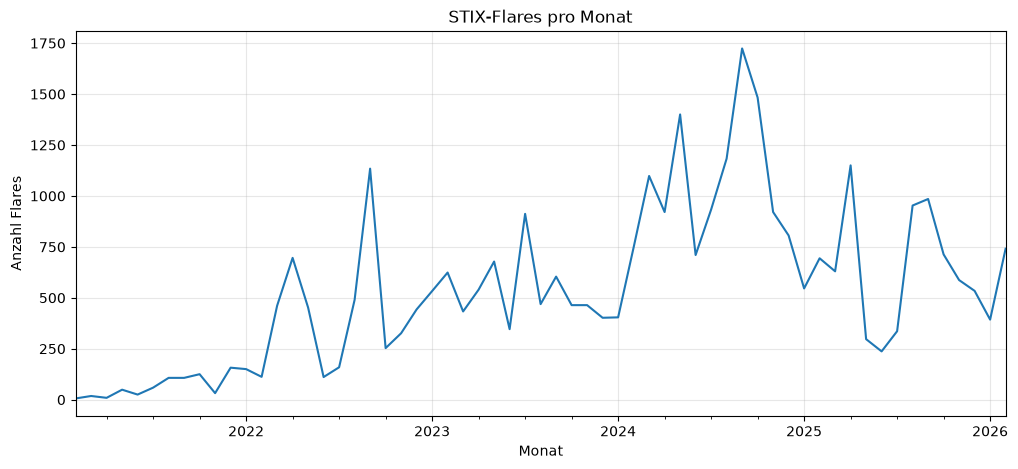

In [ ]:
# Flares pro Monat erstellen und den Verlauf plotten
monthly_flares = (
    df.dropna(subset=[DATE_COLUMN])
      .set_index(DATE_COLUMN)
      .resample("ME")
      .size()
)

monthly_flares.plot(figsize=(12, 5), title="STIX-Flares pro Monat")
plt.xlabel("Monat")
plt.ylabel("Anzahl Flares")
plt.grid(alpha=0.3)
plt.show()

## Flare-Klassen

In [ ]:
# Flares in klassen unterteilen und normalisieren
df["flare_class"] = (
    df["GOES_class_time_of_flare"]
    .replace("", pd.NA)
    .fillna(df["goes_estimated_mean_class"])
)

df["class_letter"] = (
    df["flare_class"]
    .astype("string")
    .str.strip()
    .str[0]
    .str.upper()
)

df["class_letter"].value_counts().sort_index()

class_letter
A      120
B     4027
C    26723
M     2092
X      114
Name: count, dtype: Int64

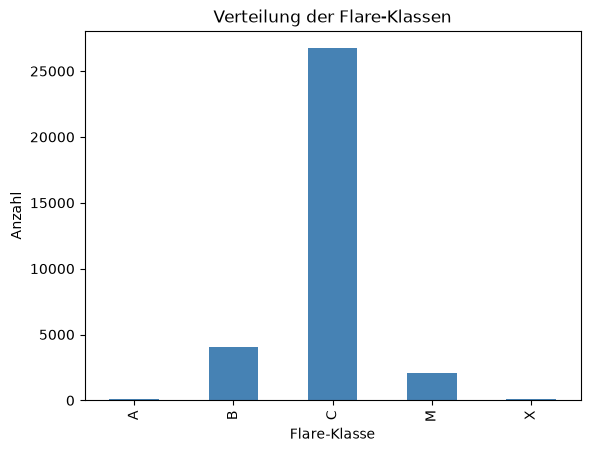

In [ ]:
# Erstellte Flare Klassen von GOES visualisieren nach Häufigkeit
df["class_letter"].value_counts().sort_index().plot(
    kind="bar",
    title="Verteilung der Flare-Klassen",
    color="steelblue"
)

plt.xlabel("Flare-Klasse")
plt.ylabel("Anzahl")
plt.show()

## Anteil starker Flares

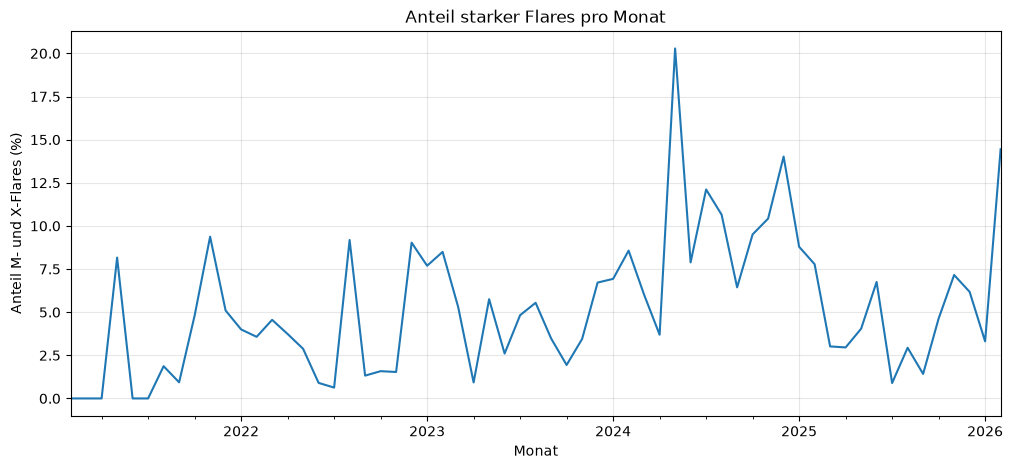

In [ ]:
# Starke GOES Flare-Klassen plotten nach PEAK-Zeitmessungen
df["strong_flare"] = df["class_letter"].isin(["M", "X"])

strong_share = (
    df.dropna(subset=[DATE_COLUMN])
      .set_index(DATE_COLUMN)["strong_flare"]
      .resample("ME")
      .mean()
      .mul(100)
)

strong_share.plot(figsize=(12, 5), title="Anteil starker Flares pro Monat")
plt.xlabel("Monat")
plt.ylabel("Anteil M- und X-Flares (%)")
plt.grid(alpha=0.3)
plt.show()

## Kurze Ergebnisse

- **Zeitraum:** Die Daten reichen ungefähr von Februar 2021 bis Februar 2026.
- **Auffällige fehlende Werte:** Bei einigen Flares fehlt die direkt beobachtete GOES-Klasse. In diesen Fällen wurde die geschätzte mittlere GOES-Klasse verwendet.
- **Entwicklung der monatlichen Aktivität:** Die monatliche Anzahl der Flares stieg bis 2024 insgesamt deutlich an. Ende 2024 wurde mit ungefähr 1.700 Flares der höchste Monatswert erreicht. Danach schwankte die Aktivität stark und nahm zeitweise ab.
- **Entwicklung des Anteils starker Flares:** Der Anteil der M- und X-Flares schwankte meistens zwischen 0 und 12 %. Mitte 2024 wurde kurzzeitig ein Höchstwert von etwa 20 % erreicht. Ein dauerhaft gleichmäßiger Anstieg ist nicht erkennbar.
- **Verteilung der Klassen:** C-Flares kommen mit großem Abstand am häufigsten vor. B- und M-Flares sind deutlich seltener; A- und X-Flares treten nur vereinzelt auf.